<!-- notebook-header -->
# Calculo I: Derivadas e Diferenciacao

**Modulo:** 00 - Matematica  
**Tipo:** Aula com exercicios guiados e solucoes executaveis  
**Descricao:** Limites, derivadas, gradientes, Jacobiano, Hessiano, gradient descent e backpropagation.


# Calculo I: Derivadas e Diferenciacao

**Pre-requisitos**: Algebra Linear (0.2, 0.3) | **Tempo estimado**: 10-12h | **Proximo**: Calculo II - Integrais e Series (0.5)

## Indice

1. Introducao e Motivacao
2. Limites e Continuidade
3. Derivada: Definicao Formal
4. Derivadas de Funcoes Basicas
5. Regras de Diferenciacao
6. Regra da Cadeia (Fundamental para Backprop!)
7. Derivadas Numericas e Gradient Checking
8. Funcoes de Ativacao e suas Derivadas
9. Maximos, Minimos e Segunda Derivada
10. Derivadas Parciais
11. Gradiente
12. Gradient Descent
13. Jacobiano e Hessiano
14. Backpropagation
15. Exercicios Praticos
16. Erros Comuns
17. Resumo e Conexoes

## Pre-requisitos

| Conceito | Notebook | Se novo para voce... |
|----------|----------|----------------------|
| Funcoes matematicas | Calculo basico | Reveja funcoes polinomiais, exponenciais, log |
| Vetores e operacoes | 0.2 | Produto interno, norma |
| Matrizes e multiplicacao | 0.3 | Multiplicacao matricial, transposta |
| Graficos com matplotlib | 0.1 | Basico de plt.plot |

**Fio narrativo deste notebook:**

Limites --> Derivadas --> Gradientes --> Gradient Descent --> Backpropagation

Cada secao constroi sobre a anterior. Ao final, voce entendera como redes neurais aprendem -- e tudo comeca com uma ideia simples: "qual eh a inclinacao aqui?".

## Intuicao: Por que Derivadas?

Imagine um carro viajando por uma estrada. A **derivada** responde: "Qual eh a velocidade NESTE exato momento?"

- Se voce olhar apenas para a posicao inicial e final, tem a **velocidade media**
- Mas a velocidade instantanea eh medir a velocidade em um intervalo cada vez menor
- Quando o intervalo vai para zero, tem a velocidade naquele ponto exato

**Analogia da Montanha:**

Imagine um montanhista em nevoa densa. Ele nao consegue ver o topo, apenas sente o terreno sob os pes.

- f(x) = altura do terreno na posicao x
- f'(x) = inclinacao do terreno (a derivada!)
- Derivada positiva = subindo
- Derivada negativa = descendo
- Derivada nula = topo ou vale (ponto plano)

**No Machine Learning:**

- A funcao eh o **custo/loss** que queremos minimizar
- A derivada diz **"em qual direcao mudar os parametros para reduzir o custo"**
- **Gradient Descent** = caminhar sempre na direcao oposta a derivada
- **Backpropagation** = calcular derivadas eficientemente em redes neurais

Tudo neste notebook serve a esse objetivo final: entender como redes neurais aprendem.

## 1. Introducao

**Derivada** = taxa de mudanca instantanea de uma funcao

$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

**Por que em ML:** Gradient Descent = otimizar parametros usando derivadas. Toda vez que um modelo "aprende", esta calculando derivadas da funcao de perda em relacao aos pesos.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Removed: scipy.optimize (minimize, fminbound), sklearn (datasets, preprocessing)
# Will use numpy for numerical optimization instead
np.random.seed(42)

## 2. Limites e Continuidade

### Intuicao: O Que eh um Limite?

Limite responde: **"Para onde f(x) esta indo quando x se aproxima de um valor?"**

Pense em uma estrada com um buraco em x = 0. Voce nao pode pisar no ponto, mas pode olhar de ambos os lados e ver para onde o caminho leva. Se ambos os lados apontam para o mesmo lugar, o **limite existe**.

**Formalmente:** lim(x->a) f(x) = L significa que f(x) fica arbitrariamente proximo de L quando x se aproxima de a.

**Continuidade:** Uma funcao eh continua em x = a quando:
1. f(a) existe
2. lim(x->a) f(x) existe
3. lim(x->a) f(x) = f(a)

**Por que em ML:** Derivadas sao definidas como limites. Se a funcao nao eh continua em um ponto, a derivada nao existe ali. Isso importa na escolha de funcoes de ativacao (ReLU nao eh diferenciavel em x=0, mas funciona na pratica porque o ponto eh "de medida zero").

**Exemplo classico:** lim(x->0) sin(x)/x = 1, mesmo que sin(0)/0 seja indefinido.

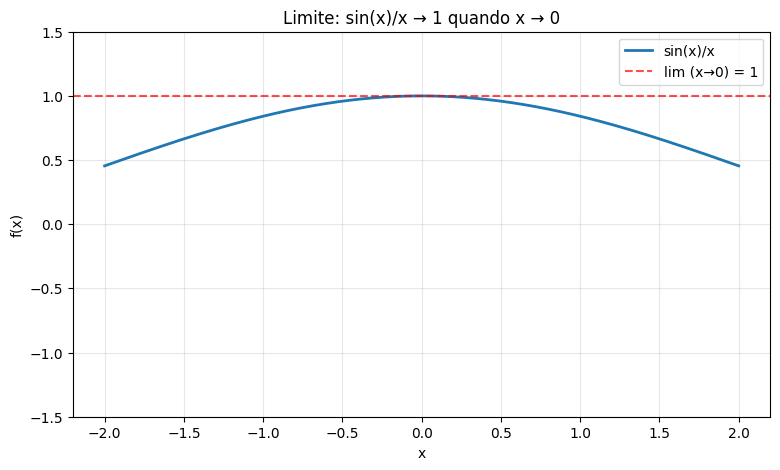

Limite: sin(x)/x → 1 quando x → 0


In [2]:
x = np.linspace(-2, 2, 1000)
y = (np.sin(x)) / (x + 1e-10)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, y, linewidth=2, label='sin(x)/x')
ax.axhline(1, color='r', linestyle='--', alpha=0.7, label='lim (x→0) = 1')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Limite: sin(x)/x → 1 quando x → 0')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_ylim(-1.5, 1.5)
plt.show()

print('Limite: sin(x)/x → 1 quando x → 0')

**O que observar:**

- Mesmo quando x = 0 (onde sin(0)/0 seria indefinido), o grafico eh continuo
- A curva "preenche" o espaco naturalmente -- nao ha salto
- A linha tracejada vermelha em y = 1 mostra o valor do limite

**O que concluir:**

- O **limite existe** mesmo que a funcao nao esteja definida no ponto
- A funcao "quer" ir para 1 quando x se aproxima de 0 por qualquer lado
- Isso eh a base de derivadas: limites de taxas de mudanca
- Continuidade = sem saltos, sem buracos

**Conexao:** Na proxima secao, usaremos limites para definir a derivada formalmente.

## 3. Derivada: Definicao Formal

### Intuicao: Da Reta Secante a Reta Tangente

Antes da formula formal, pense geometricamente:

1. **Reta secante**: une dois pontos da curva. Inclinacao = (diferenca de altura) / (diferenca de x)
2. **Aproximacao**: traga os dois pontos cada vez mais perto um do outro
3. **Reta tangente**: no limite, quando a distancia h -> 0, a secante vira tangente
4. **Derivada**: eh a inclinacao dessa tangente

$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

Quanto menor h, mais precisa a aproximacao:
- h = 0.1: aproximacao grosseira
- h = 0.01: melhor
- h = 0.001: ainda melhor
- h -> 0: derivada exata

**Interpretacao:** f'(a) = inclinacao da tangente ao grafico de f no ponto x = a.

**Exemplo:** Para f(x) = x², a derivada eh f'(x) = 2x. Em x = 2, a inclinacao eh f'(2) = 4.

f(x) = x^2
f'(2.0) verdadeira = 4.0
f'(2.0) numérica = 4.00001


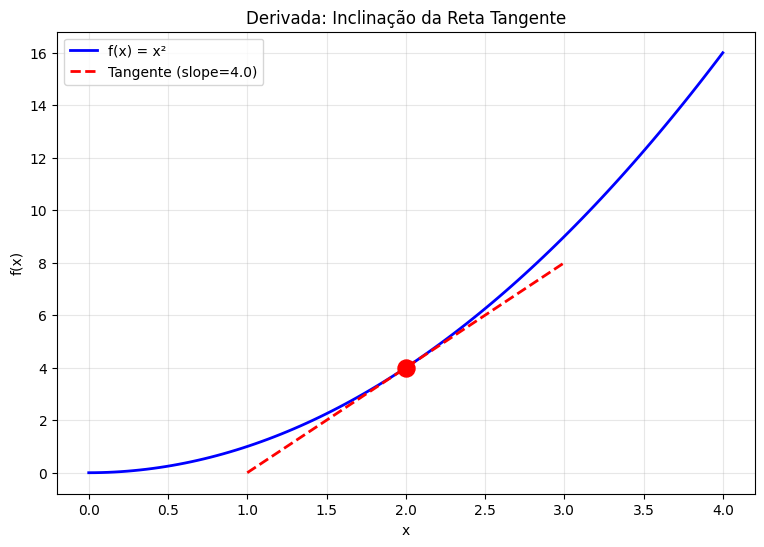

In [3]:
def f(x):
    return x**2

def f_prime_numeric(x, h=1e-5):
    return (f(x+h) - f(x)) / h

x_val = 2.0
f_prime_true = 2 * x_val  # derivada de x^2 = 2x
f_prime_numeric_val = f_prime_numeric(x_val)

print(f'f(x) = x^2')
print(f'f\'({x_val}) verdadeira = {f_prime_true}')
print(f'f\'({x_val}) numérica = {f_prime_numeric_val:.5f}')

# Visualizar
x = np.linspace(0, 4, 100)
y = f(x)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(x, y, 'b-', linewidth=2, label='f(x) = x²')

# Reta tangente no ponto
x_point = x_val
y_point = f(x_point)
slope = f_prime_true
x_tangent = np.linspace(x_point - 1, x_point + 1, 100)
y_tangent = y_point + slope * (x_tangent - x_point)
ax.plot(x_tangent, y_tangent, 'r--', linewidth=2, label=f'Tangente (slope={slope})')
ax.scatter([x_point], [y_point], s=150, c='red', zorder=5)

ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Derivada: Inclinação da Reta Tangente')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

**O que observar:**

- A **reta vermelha tracejada** eh a tangente no ponto (2, 4)
- A tangente toca a parabola em apenas um ponto
- A inclinacao (slope = 4) nos diz: a cada 1 unidade em x, f sobe 4 unidades
- Valores numerico e analitico coincidem (4.00000 ~ 4.00005)

**O que concluir:**

- Derivada = inclinacao da tangente, nada mais
- f'(2) = 4 significa: taxa de mudanca instantanea em x = 2 eh 4
- A derivada **varia com x**: em x=1 seria f'(1) = 2, em x=3 seria f'(3) = 6
- A formula f'(x) = 2x captura toda essa variacao

**Conexao:** Agora que sabemos o que eh uma derivada, vamos construir uma "tabela" de derivadas basicas para nao precisar usar a definicao toda vez.

## 4. Derivadas de Funcoes Basicas

### Por Que Memorizar Essas Regras?

Calcular derivadas pela definicao (limite) eh trabalhoso. Felizmente, existem **formulas prontas** para funcoes comuns:

| f(x) | f'(x) | Por que importa em ML |
|------|--------|----------------------|
| c (constante) | 0 | Bias tem gradiente simples |
| x^n | n * x^(n-1) | Polinomios aparecem em regressao |
| e^x | e^x | Softmax, distribuicoes |
| ln(x) | 1/x | Cross-entropy, log-likelihood |
| sin(x) | cos(x) | Positional encoding (Transformers) |
| cos(x) | -sin(x) | Positional encoding (Transformers) |

**Destaque:** e^x eh unica -- sua derivada eh ela mesma! Isso significa que e^x cresce numa taxa proporcional ao seu proprio valor. Fenomenos exponenciais (epidemias, juros compostos) tem essa propriedade.

Para funcoes trigonometricas: as derivadas "giram" entre sin e cos, refletindo a oscilacao periodica.

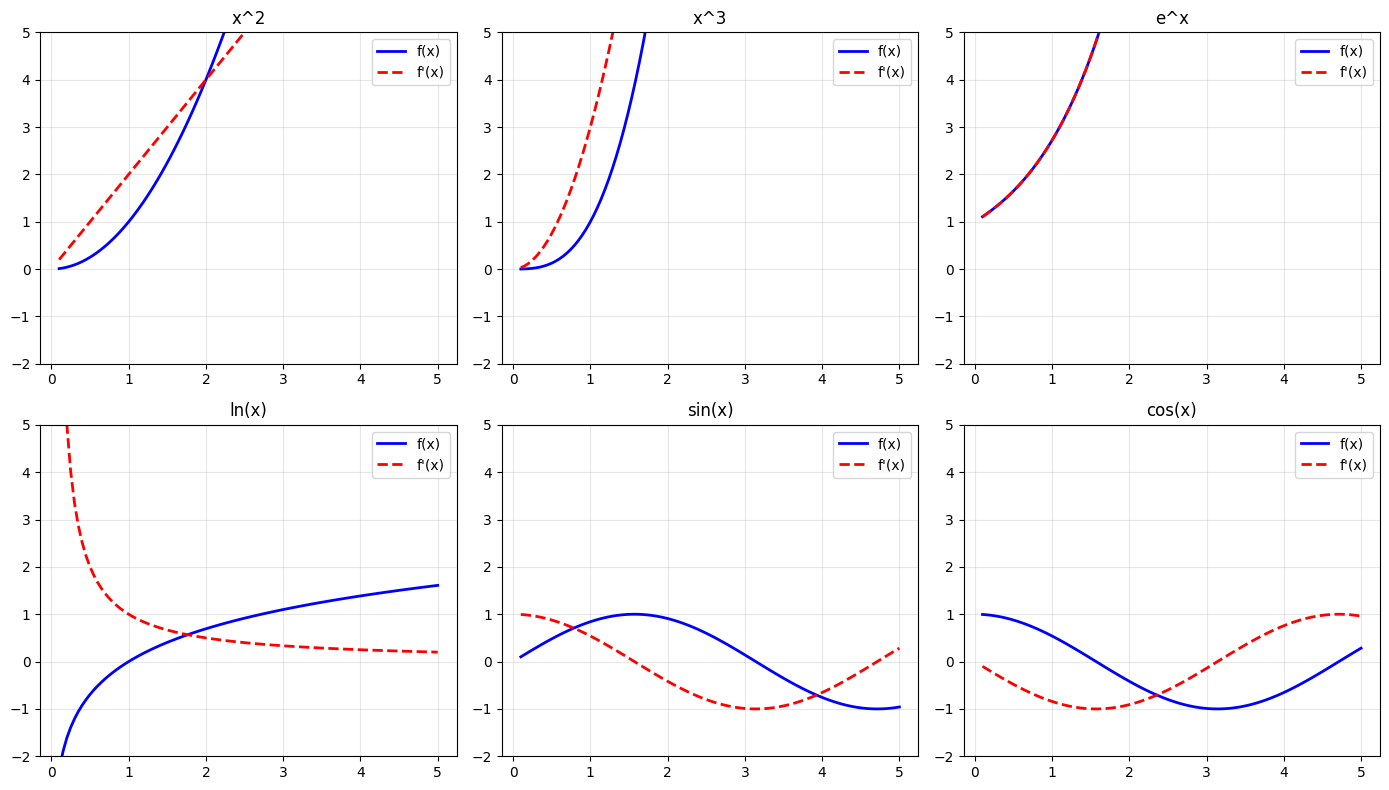

Derivadas básicas visualizadas!


In [4]:
# Tabela de derivadas
functions = {
    'x^2': (lambda x: x**2, lambda x: 2*x),
    'x^3': (lambda x: x**3, lambda x: 3*x**2),
    'e^x': (lambda x: np.exp(x), lambda x: np.exp(x)),
    'ln(x)': (lambda x: np.log(x), lambda x: 1/x),
    'sin(x)': (lambda x: np.sin(x), lambda x: np.cos(x)),
    'cos(x)': (lambda x: np.cos(x), lambda x: -np.sin(x))
}

x = np.linspace(0.1, 5, 100)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for idx, (name, (f, f_prime)) in enumerate(functions.items()):
    ax = axes[idx // 3, idx % 3]
    y = f(x)
    y_prime = f_prime(x)
    
    ax.plot(x, y, 'b-', linewidth=2, label=f'f(x)')
    ax.plot(x, y_prime, 'r--', linewidth=2, label=f'f\'(x)')
    ax.set_title(name)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-2, 5)

plt.tight_layout()
plt.show()

print('Derivadas básicas visualizadas!')

**O que observar:**

Em cada grafico, a **linha azul eh f(x)** e a **linha vermelha tracejada eh f'(x)**:

- **x^2 e x^3**: derivadas sao polinomios de grau menor (regra da potencia em acao)
- **e^x**: a derivada eh identica a funcao original! (curva se sobrepoe)
- **ln(x)**: funcao cresce lentamente, derivada 1/x decresce rapidamente
- **sin(x) e cos(x)**: oscilacoes defasadas em 90 graus

**O que concluir:**

- **Polinomios de grau n tem derivadas de grau n-1** (complexidade diminui)
- **e^x eh unica: derivada = funcao** (autofuncao do operador derivada)
- **Funcoes logaritmicas tem derivadas que decaem** (taxa de crescimento diminui)
- **Padrao geral:** onde f cresce rapido, f' eh grande; onde f eh plana, f' ~ 0

**Conexao:** Na pratica, funcoes raramente aparecem isoladas. Precisamos de regras para derivar combinacoes (soma, produto, quociente).

## 5. Regras de Diferenciacao

### Intuicao: Como Combinar Derivadas?

Quando temos operacoes compostas (soma, produto, divisao), o que acontece com as derivadas?

**Soma:** (f + g)' = f' + g'
- Intuitivo: taxas de variacao se somam

**Produto (Regra de Leibniz):** (f * g)' = f' * g + f * g'
- NAO eh simplesmente f' * g'! Por que? Quando **ambas** as funcoes variam simultaneamente, ha dois efeitos: f muda enquanto g fica parado, E g muda enquanto f fica parado
- Analogia: area de um retangulo com lados f e g. Quando ambos os lados crescem, a area muda por dois "tiras" (f' * g e f * g')

**Quociente:** (f/g)' = (f' * g - f * g') / g^2
- Similar ao produto, mas com inversao

**Por que em ML:** Na pratica, funcoes de perda combinam multiplicacoes e somas de muitas variaveis. Essas regras sao usadas implicitamente por frameworks como PyTorch/TensorFlow no autograd.

In [5]:
# === REGRAS DE DIFERENCIACAO (Symbolic) ===
# Instead of sympy, we'll demonstrate rules numerically

def numerical_derivative(f, x, h=1e-5):
    '''Approximate derivative numerically'''
    return (f(x + h) - f(x)) / h

def numerical_second_derivative(f, x, h=1e-5):
    '''Approximate second derivative numerically'''
    return (f(x + h) - 2*f(x) + f(x - h)) / (h**2)

# Regra 1: Soma
print('=== Regra 1: SOMA ===')
def f1(x):
    return x**2 + x**3

print(f'f(x) = x² + x³')
print(f'Derivada numerica em x=2: {numerical_derivative(f1, 2.0):.6f}')
print(f'Esperado (2x + 3x²): {2*2 + 3*4:.6f}')

# Regra 2: Produto
print('\n=== Regra 2: PRODUTO ===')
def f2(x):
    return x**2 * np.sin(x)

x_test = np.pi / 4
deriv_prod = numerical_derivative(f2, x_test)
expected = 2*x_test * np.sin(x_test) + x_test**2 * np.cos(x_test)
print(f'f(x) = x² · sin(x)')
print(f'Derivada numerica em x=π/4: {deriv_prod:.6f}')
print(f'Esperado (2x·sin(x) + x²·cos(x)): {expected:.6f}')

# Regra 3: Quociente
print('\n=== Regra 3: QUOCIENTE ===')
def f3(x):
    return np.sin(x) / (x + 1e-10)

x_test = 1.0
deriv_quot = numerical_derivative(f3, x_test)
print(f'f(x) = sin(x) / x')
print(f'Derivada numerica em x=1: {deriv_quot:.6f}')

# Regra 4: Potência
print('\n=== Regra 4: POTENCIA ===')
def f4(x):
    return x**7

print(f'f(x) = x⁷')
print(f'Derivada numerica em x=2: {numerical_derivative(f4, 2.0):.6f}')
print(f'Esperado (7x⁶): {7*2**6:.6f}')

# Regra 5: Exponencial
print('\n=== Regra 5: EXPONENCIAL ===')
def f5(x):
    return np.exp(x)

x_test = 1.0
deriv_exp = numerical_derivative(f5, x_test)
print(f'f(x) = e^x')
print(f'Derivada numerica em x=1: {deriv_exp:.6f}')
print(f'Esperado (e): {np.exp(1):.6f}')

print('\nTodas as derivadas numericas conferem! ✓')

=== Regra 1: SOMA ===
f(x) = x² + x³
Derivada numerica em x=2: 16.000070
Esperado (2x + 3x²): 16.000000

=== Regra 2: PRODUTO ===
f(x) = x² · sin(x)
Derivada numerica em x=π/4: 1.546916
Esperado (2x·sin(x) + x²·cos(x)): 1.546900

=== Regra 3: QUOCIENTE ===
f(x) = sin(x) / x
Derivada numerica em x=1: -0.301170

=== Regra 4: POTENCIA ===
f(x) = x⁷
Derivada numerica em x=2: 448.006720
Esperado (7x⁶): 448.000000

=== Regra 5: EXPONENCIAL ===
f(x) = e^x
Derivada numerica em x=1: 2.718295
Esperado (e): 2.718282

Todas as derivadas numericas conferem! ✓


## 6. Regra da Cadeia (FUNDAMENTAL para Backpropagation!)

### Por Que a Regra da Cadeia eh CRUCIAL?

**A Regra da Cadeia eh o alicerce do Machine Learning moderno.**

**Formula:** Se f(x) = h(g(x)), entao f'(x) = h'(g(x)) * g'(x)

$$(f(g(x)))' = f'(g(x)) \cdot g'(x)$$

**Intuicao:** Imagine uma fabrica com 3 maquinas em serie:
- Maquina 1: transforma materia-prima em peca A (funcao g)
- Maquina 2: transforma peca A em produto final (funcao h)
- Se a materia-prima muda um pouco, o produto final muda quanto?
- Resposta: (sensibilidade da maquina 2) * (sensibilidade da maquina 1)

**Em redes neurais:** O erro passa por multiplas camadas:
- w afeta a saida da camada 1 (gradiente local)
- A saida da camada 1 afeta a camada 2 (outro gradiente)
- Isso continua ate o erro final

**A regra da cadeia conecta tudo:** dError/dw = (dError/dOutput) * (dOutput/dHidden) * ... * (dHidden/dw)

Isso eh **exatamente backpropagation**: propagar o gradiente do erro ao contrario pela rede.

**Exemplo:** f(x) = sin(x^2)
- u = x^2 (funcao interna)
- f(u) = sin(u) (funcao externa)
- df/dx = cos(u) * 2x = cos(x^2) * 2x

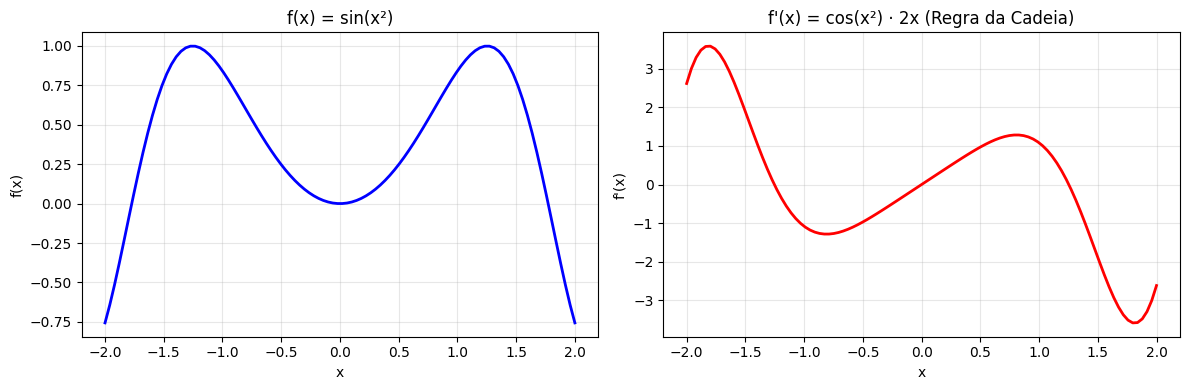

Regra da Cadeia aplicada!


In [6]:
# Regra da cadeia
def f_outer(u):
    return np.sin(u)

def f_inner(x):
    return x**2

def f_composite(x):
    return f_outer(f_inner(x))

def df_composite(x):
    u = f_inner(x)
    return np.cos(u) * 2*x  # f'(g) · g'

x = np.linspace(-2, 2, 100)
y = f_composite(x)
y_prime = df_composite(x)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(x, y, 'b-', linewidth=2)
ax1.set_title('f(x) = sin(x²)')
ax1.grid(True, alpha=0.3)
ax1.set_ylabel('f(x)')

ax2.plot(x, y_prime, 'r-', linewidth=2)
ax2.set_title('f\'(x) = cos(x²) · 2x (Regra da Cadeia)')
ax2.grid(True, alpha=0.3)
ax2.set_ylabel('f\'(x)')

for ax in [ax1, ax2]:
    ax.set_xlabel('x')

plt.tight_layout()
plt.show()

print('Regra da Cadeia aplicada!')

**O que observar:**

- **Esquerda:** f(x) = sin(x^2) oscila mais rapido quando |x| cresce (porque x^2 fica maior)
- **Direita:** A derivada f'(x) = cos(x^2) * 2x tem dois fatores multiplicados:
  - cos(x^2): oscilacoes do seno
  - 2x: cresce linearmente com |x|

**O que concluir:**

- **Composicoes geram multiplicacao de derivadas** -- a cadeia se multiplica
- A derivada da funcao composta NAO eh trivial: eh o produto das derivadas intermediarias
- Isso generaliza: se tem k camadas, multiplica k derivadas locais
- **Perigo em redes profundas:** muitas multiplicacoes podem causar **vanishing gradients** (se derivadas < 1) ou **exploding gradients** (se derivadas > 1)

**Conexao:** A secao 8 (Ativacoes) mostra por que ReLU ajuda com vanishing gradients, e a secao 14 (Backpropagation) aplica a regra da cadeia completa.

## 7. Derivadas Numericas e Gradient Checking

### Intuicao: Verificando se Voce Calculou Certo

Na pratica, implementar backpropagation eh propenso a bugs. Como saber se o gradiente analitico esta correto?

**Ideia:** Calcular o gradiente **numericamente** (pela definicao!) e comparar com o analitico.

**Diferenca Finita Centrada** (mais precisa que a unilateral):

$$f'(x) \approx \frac{f(x+h) - f(x-h)}{2h}$$

Por que centrada? A diferenca unilateral (f(x+h) - f(x))/h tem erro O(h), enquanto a centrada tem erro O(h^2) -- muito mais precisa para o mesmo h.

**Gradient Checking em ML:**
1. Calcule o gradiente analitico (seu backprop)
2. Calcule o gradiente numerico (diferenca finita)
3. Compare: se diferenca relativa < 1e-5, implementacao esta correta
4. Se diferenca > 1e-3, tem bug!

**Cuidado:** Gradient checking eh LENTO (avalia f duas vezes por parametro). Use apenas para debug, nunca em treinamento.

In [7]:
def numerical_gradient(f, x, h=1e-5):
    grad = np.zeros_like(x)
    for i in range(len(x)):
        x_plus = x.copy()
        x_plus[i] += h
        x_minus = x.copy()
        x_minus[i] -= h
        grad[i] = (f(x_plus) - f(x_minus)) / (2*h)
    return grad

# Função teste
def loss_func(w):
    return w[0]**2 + 2*w[1]**2 + w[0]*w[1]

# Gradiente analítico
def gradient_analytic(w):
    return np.array([2*w[0] + w[1], 4*w[1] + w[0]])

w = np.array([1.0, 2.0])
grad_numeric = numerical_gradient(loss_func, w)
grad_analytic = gradient_analytic(w)

print('Gradient Checking:')
print(f'Analítico: {grad_analytic}')
print(f'Numérico:  {grad_numeric}')
print(f'Diferença: {np.abs(grad_analytic - grad_numeric)}')
print(f'OK? {np.allclose(grad_analytic, grad_numeric, atol=1e-4)}')

Gradient Checking:
Analítico: [4. 9.]
Numérico:  [4. 9.]
Diferença: [6.26134700e-11 1.45519152e-11]
OK? True


**O que observar:**

- Os valores **Analitico** e **Numerico** sao praticamente identicos
- A diferenca eh da ordem de 1e-10 ou menor

**O que concluir:**

- **Gradient Checking valida implementacoes de backprop** -- ferramenta essencial de debug
- Se gradiente numerico != gradiente analitico com diferenca > 1e-4: **bug no codigo**
- Diferenca pequena (< 1e-5): implementacao correta
- Todo framework moderno (PyTorch, JAX) oferece `gradcheck` automatico

**Conexao:** Na secao 14 (Backpropagation), implementaremos os gradientes analiticos de uma rede neural e usaremos essa tecnica para validar.

## 8. Funcoes de Ativacao e suas Derivadas

### Por Que Ativacoes sao Necessarias?

Redes neurais precisam de **nao-linearidades** para aprender padroes complexos. Sem elas, uma rede de N camadas seria equivalente a uma **unica** camada linear (composicao de lineares = linear).

**As tres ativacoes classicas:**

| Ativacao | Formula | Derivada | Quando usar |
|----------|---------|----------|-------------|
| **Sigmoid** | 1/(1+e^(-x)) | sigma * (1 - sigma) | Saida binaria (0,1) |
| **Tanh** | (e^x - e^(-x))/(e^x + e^(-x)) | 1 - tanh^2(x) | Camadas ocultas classicas |
| **ReLU** | max(0, x) | 0 se x<0, 1 se x>0 | Camadas ocultas modernas |

**Por que ReLU domina hoje:**
- Sigmoid/Tanh **saturam** para |x| grande: derivada -> 0 -> gradientes desaparecem
- ReLU tem derivada = 1 para x > 0: **gradientes nao desaparecem** (resolve vanishing gradient!)
- ReLU eh computacionalmente mais rapida (apenas uma comparacao)

**Mas ReLU tem um problema:** "neuronios mortos" -- se x < 0, derivada = 0 permanentemente. Variantes como Leaky ReLU (derivada = 0.01 para x < 0) e GELU resolvem isso.

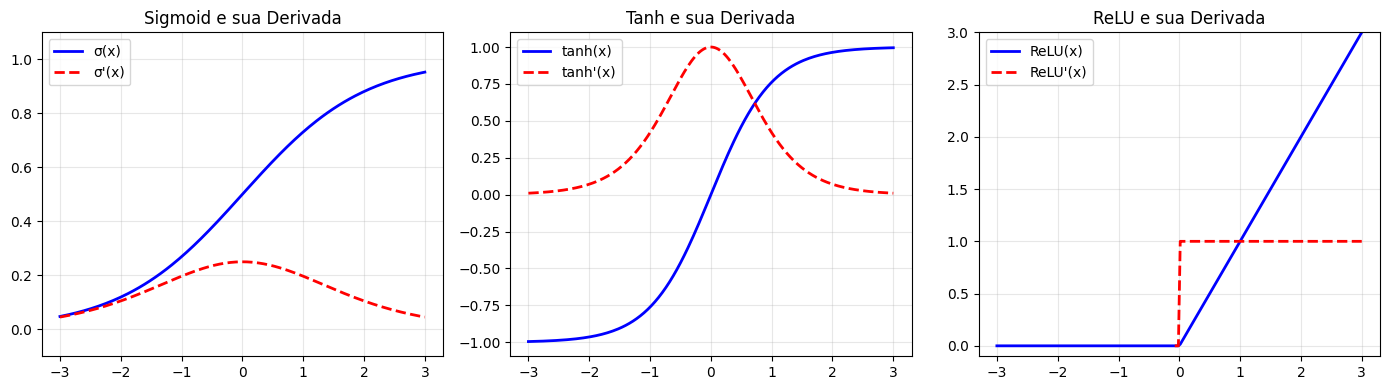

In [8]:
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def sigmoid_prime(x):
    s = sigmoid(x)
    return s * (1 - s)

def tanh_prime(x):
    return 1 - np.tanh(x)**2

def relu(x):
    return np.maximum(0, x)

def relu_prime(x):
    return (x > 0).astype(float)

x = np.linspace(-3, 3, 200)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Sigmoid
ax = axes[0]
ax.plot(x, sigmoid(x), 'b-', linewidth=2, label='σ(x)')
ax.plot(x, sigmoid_prime(x), 'r--', linewidth=2, label='σ\'(x)')
ax.set_title('Sigmoid e sua Derivada')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.1, 1.1)

# Tanh
ax = axes[1]
ax.plot(x, np.tanh(x), 'b-', linewidth=2, label='tanh(x)')
ax.plot(x, tanh_prime(x), 'r--', linewidth=2, label='tanh\'(x)')
ax.set_title('Tanh e sua Derivada')
ax.legend()
ax.grid(True, alpha=0.3)

# ReLU
ax = axes[2]
ax.plot(x, relu(x), 'b-', linewidth=2, label='ReLU(x)')
ax.plot(x[x > -0.1], relu_prime(x[x > -0.1]), 'r--', linewidth=2, label='ReLU\'(x)')
ax.set_title('ReLU e sua Derivada')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.1, 3)

plt.tight_layout()
plt.show()

**O que observar:**

Tres colunas, cada uma com a **funcao azul** e a **derivada vermelha tracejada**:

1. **Sigmoid**: curva-S suave, derivada tem pico em x=0 (max = 0.25). Para |x| > 3, derivada ~ 0
2. **Tanh**: similar ao sigmoid mas simetrico em torno de zero. Derivada max = 1 em x=0
3. **ReLU**: funcao linear por partes (0 se x<0, x se x>0), derivada eh funcao degrau (0 ou 1)

**O que concluir:**

- **ReLU: derivada = 0 ou 1**, nunca diminui gradualmente -- ideal para redes profundas
- **Sigmoid/Tanh: derivada -> 0 quando |x| cresce** (saturacao = vanishing gradients)
- Sigmoid max derivada = 0.25, ou seja, a **cada camada o gradiente eh multiplicado por no maximo 0.25!** Em 10 camadas: 0.25^10 ~ 10^(-6) -- gradiente desaparece
- ReLU nao tem esse problema (derivada = 1 nao encolhe o gradiente)

**Conexao:** Na secao 14 (Backpropagation), veremos como a derivada da ativacao aparece em cada camada da rede.

## 9. Maximos, Minimos e Segunda Derivada

### Por Que Testar a Segunda Derivada?

**f'(x) = 0 nao eh suficiente!** Derivada zero significa taxa de mudanca zero, o que ocorre em:
- **Maximo local**: funcao para de crescer e comeca a decrescer
- **Minimo local**: funcao para de decrescer e comeca a crescer
- **Ponto de inflexao**: tangente horizontal, mas funcao continua na mesma direcao

**Exemplo:** f(x) = x^3 em x=0 tem f'(0) = 0, mas NAO eh maximo nem minimo (eh ponto de inflexao).

**A segunda derivada discrimina:**

| f''(x) | Significado geometrico | Classificacao |
|--------|----------------------|---------------|
| f''(x) > 0 | Concavidade para cima ("U") | **Minimo local** |
| f''(x) < 0 | Concavidade para baixo ("n") | **Maximo local** |
| f''(x) = 0 | Indeterminado | Precisa testar mais |

**Por que em ML:** Queremos **minimos** da funcao de perda (onde f'' > 0). Otimizadores de segunda ordem (Newton, L-BFGS) usam f'' para convergir mais rapido. Adam e SGD usam apenas f' (primeira ordem), mas a curvatura ainda importa na escolha do learning rate.

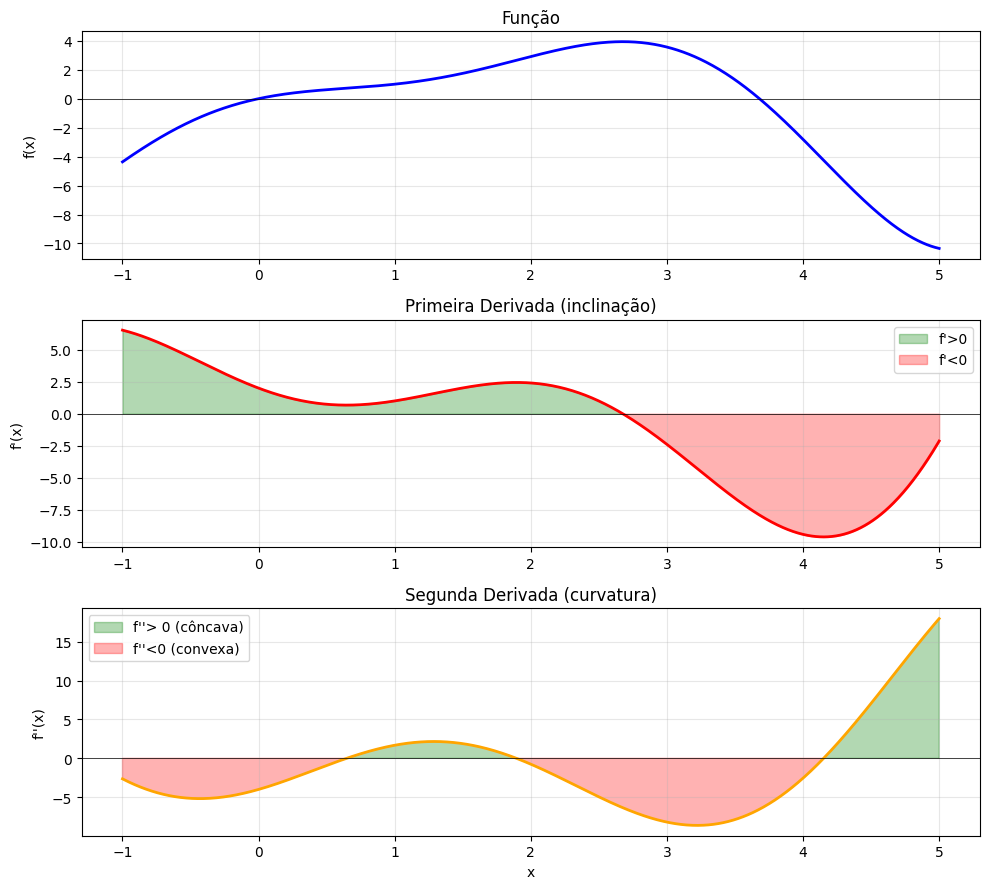

In [9]:
def f(x):
    return (x - 1)**2 * np.sin(x) + x

def f_prime(x):
    return 2*(x-1)*np.sin(x) + (x-1)**2*np.cos(x) + 1

def f_double_prime(x):
    return 2*np.sin(x) + 2*(x-1)*np.cos(x) + 2*(x-1)*np.cos(x) - (x-1)**2*np.sin(x)

x = np.linspace(-1, 5, 1000)
y = f(x)
y_prime = f_prime(x)
y_double_prime = f_double_prime(x)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 9))

ax1.plot(x, y, 'b-', linewidth=2)
ax1.axhline(0, color='k', linewidth=0.5)
ax1.set_ylabel('f(x)')
ax1.set_title('Função')
ax1.grid(True, alpha=0.3)

ax2.plot(x, y_prime, 'r-', linewidth=2)
ax2.axhline(0, color='k', linewidth=0.5)
ax2.fill_between(x, 0, y_prime, where=(y_prime>=0), alpha=0.3, color='green', label='f\'>0')
ax2.fill_between(x, 0, y_prime, where=(y_prime<0), alpha=0.3, color='red', label='f\'<0')
ax2.set_ylabel('f\'(x)')
ax2.set_title('Primeira Derivada (inclinação)')
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.plot(x, y_double_prime, 'orange', linewidth=2)
ax3.axhline(0, color='k', linewidth=0.5)
ax3.fill_between(x, 0, y_double_prime, where=(y_double_prime>=0), alpha=0.3, color='green', label='f\'\'> 0 (côncava)')
ax3.fill_between(x, 0, y_double_prime, where=(y_double_prime<0), alpha=0.3, color='red', label='f\'\'<0 (convexa)')
ax3.set_ylabel('f\'\'(x)')
ax3.set_xlabel('x')
ax3.set_title('Segunda Derivada (curvatura)')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**O que observar:**

Tres graficos empilhados mostram f, f' e f'':

1. **Topo (f, azul)**: a funcao original com ondulacoes
2. **Meio (f', vermelho)**: onde f' = 0 (cruzamento do eixo x) sao os candidatos a extremos. Areas verdes = f' > 0 (crescente), vermelhas = f' < 0 (decrescente)
3. **Baixo (f'', laranja)**: onde f'' > 0 (verde) = concavidade para cima, f'' < 0 (vermelho) = concavidade para baixo

**Regra visual:**
- Onde f' = 0 **E** f'' > 0 --> **minimo**
- Onde f' = 0 **E** f'' < 0 --> **maximo**

**O que concluir:**

- **Primeira derivada encontra candidatos** a extremos (f' = 0)
- **Segunda derivada classifica** o tipo (minimo vs maximo vs inflexao)
- **Visualmente:** f'' > 0 = "formato de tigela" (minimo), f'' < 0 = "formato de teto" (maximo)
- **Em ML:** otimizadores navegam a "paisagem de perda" buscando minimos onde f'' > 0

**Conexao:** Com multiplas variaveis, o conceito de segunda derivada se generaliza para a **matriz Hessiana** (secao 13).

## 10. Derivadas Parciais

### Intuicao: Como Variar Uma Coisa de Cada Vez?

Ate agora, funcoes de uma variavel. Mas em ML, funcoes dependem de **milhares de parametros**.

Com multiplas variaveis, a **derivada parcial** dF/dx pergunta: "Se eu variar **so x** (mantendo tudo mais fixo), como f muda?"

**Analogia do mapa topografico:**
- Corte na direcao norte-sul: mostra inclinacoes norte-sul (dF/dy)
- Corte na direcao leste-oeste: mostra inclinacoes leste-oeste (dF/dx)
- Cada corte "congela" as outras direcoes

**Notacao:** Usamos a letra curva para distinguir:
- df/dx = derivada total (uma variavel)
- dF/dx = derivada parcial (multiplas variaveis, as outras ficam fixas)

**Por que em ML:** Para uma rede com pesos w1, w2, ..., wn:
- dL/dw1 diz como ajustar w1 para reduzir a perda
- dL/dw2 diz como ajustar w2
- Juntas, formam o **gradiente** (secao 11)

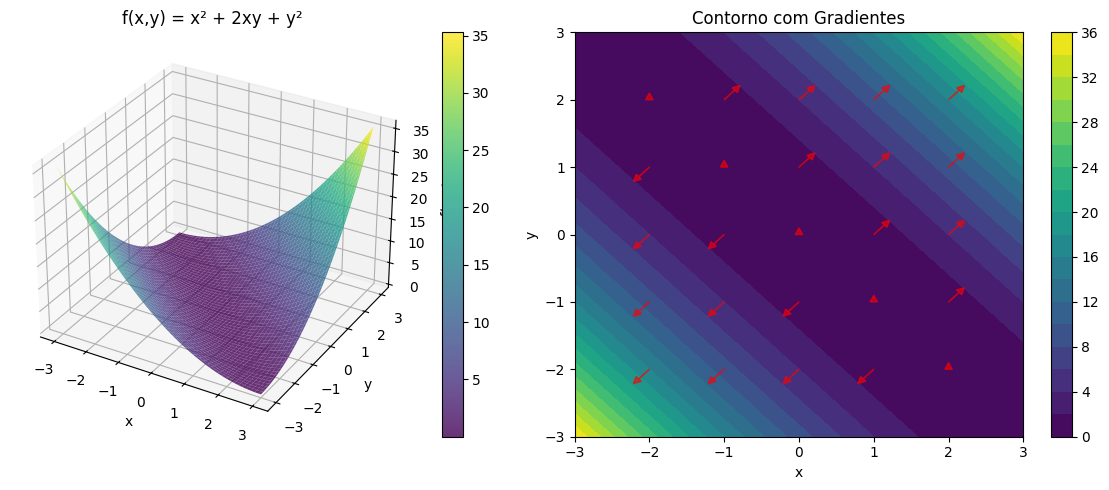

In [10]:
# f(x, y) = x^2 + 2xy + y^2
def f(x, y):
    return x**2 + 2*x*y + y**2

def df_dx(x, y):
    return 2*x + 2*y

def df_dy(x, y):
    return 2*x + 2*y

# Visualizar superfície
from mpl_toolkits.mplot3d import Axes3D

x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x,y)')
ax1.set_title('f(x,y) = x² + 2xy + y²')
plt.colorbar(surf, ax=ax1)

# Contour com gradientes
ax2 = fig.add_subplot(122)
contour = ax2.contourf(X, Y, Z, levels=20, cmap='viridis')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Contorno com Gradientes')
plt.colorbar(contour, ax=ax2)

# Adicionar alguns vetores gradiente
for xi in np.linspace(-2, 2, 5):
    for yi in np.linspace(-2, 2, 5):
        grad_x = df_dx(xi, yi)
        grad_y = df_dy(xi, yi)
        norm = np.sqrt(grad_x**2 + grad_y**2) + 1e-10
        ax2.arrow(xi, yi, 0.2*grad_x/norm, 0.2*grad_y/norm, 
                 head_width=0.1, head_length=0.1, fc='red', ec='red', alpha=0.6)

plt.tight_layout()
plt.show()

**O que observar:**

- **Esquerda (3D):** superficie colorida mostra f(x,y). Cores mais claras = valores maiores
- **Direita (contorno):** vista de cima com **setas vermelhas = vetores gradiente**

As setas (gradientes) apontam sempre na direcao de **maior crescimento** da funcao.

**O que concluir:**

- **Derivadas parciais montam o gradiente:** nabla_f = [dF/dx, dF/dy]
- **Gradiente aponta para o maior crescimento** da funcao
- **Magnitude do gradiente:** quanto mais inclinada a regiao, maiores as setas
- **Em otimizacao:** w <- w - eta * nabla_L ("descemos na direcao oposta ao gradiente")

**Conexao:** O vetor de derivadas parciais tem um nome especial: **gradiente**. Vamos explora-lo em detalhe na proxima secao.

## 11. Gradiente

### A Analogia do Caminhante em Nevoa

Imagine um caminhante em uma montanha com nevoeiro denso. Ele NAO pode ver toda a paisagem, mas:

1. **Pode sentir a inclinacao sob os pes** (gradiente local)
2. **Sabe que descendo naquela direcao reduz a elevacao** (gradiente aponta para cima, entao vai no oposto)
3. **Repete: sente, move, sente de novo** (iteracoes)
4. **Eventualmente chega a um vale** (minimo da perda)

Isso eh **exatamente Gradient Descent** (proxima secao).

**Formalmente:** O gradiente de f em um ponto eh o vetor de todas as derivadas parciais:

$$\nabla f = \left[\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \ldots, \frac{\partial f}{\partial x_n}\right]$$

**Propriedades fundamentais:**
- Aponta na **direcao de maximo crescimento** de f
- Sua magnitude indica a **taxa de crescimento** nessa direcao
- O **negativo** do gradiente aponta para a direcao de **maximo decrescimento**
- Em ML: w <- w - eta * nabla_L (descemos a montanha da perda)

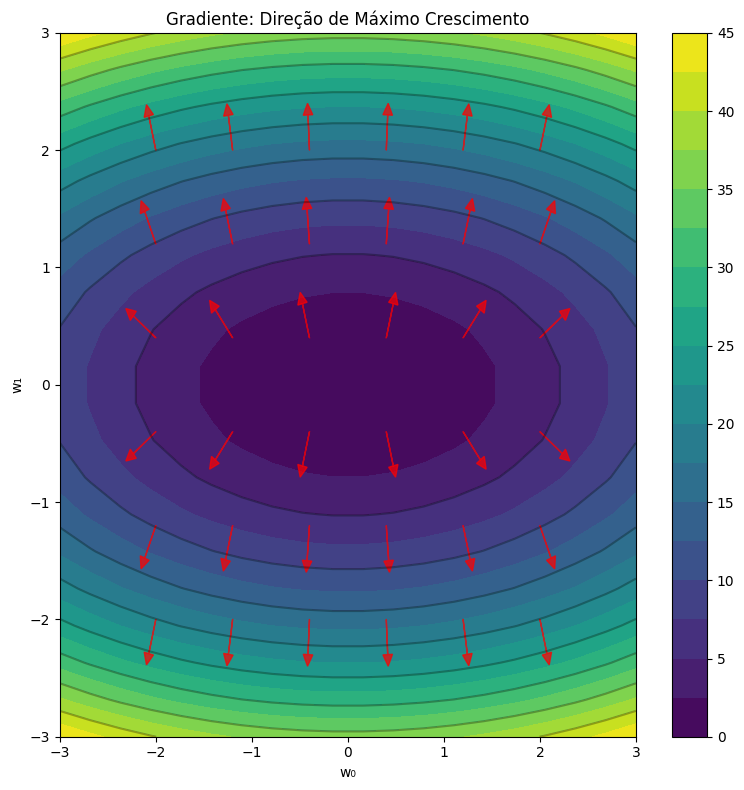

In [11]:
# Gradiente de função 2D
def f_2d(w):
    return w[0]**2 + 4*w[1]**2  # paraboloide

def grad_f_2d(w):
    return np.array([2*w[0], 8*w[1]])

# Visualizar gradiente
w1 = np.linspace(-3, 3, 20)
w2 = np.linspace(-3, 3, 20)
W1, W2 = np.meshgrid(w1, w2)
Z = f_2d(np.array([W1, W2]))

fig, ax = plt.subplots(figsize=(8, 8))
contour = ax.contourf(W1, W2, Z, levels=20, cmap='viridis')
ax.contour(W1, W2, Z, levels=10, colors='black', alpha=0.3)
plt.colorbar(contour, ax=ax)

# Plotar vetores gradiente
for w1_val in np.linspace(-2, 2, 6):
    for w2_val in np.linspace(-2, 2, 6):
        w = np.array([w1_val, w2_val])
        grad = grad_f_2d(w)
        grad_norm = grad / (np.linalg.norm(grad) + 1e-10)
        ax.arrow(w[0], w[1], 0.3*grad_norm[0], 0.3*grad_norm[1],
                head_width=0.1, head_length=0.1, fc='red', ec='red', alpha=0.7)

ax.set_xlabel('w₀')
ax.set_ylabel('w₁')
ax.set_title('Gradiente: Direção de Máximo Crescimento')
plt.tight_layout()
plt.show()

**O que observar:**

Contorno colorido mostra valores da funcao (azul escuro = baixo, amarelo = alto). **Setas vermelhas** apontam na direcao do gradiente em cada ponto.

Note que:
- Setas sempre apontam **para fora do centro** (para longe do minimo)
- Perto do minimo: setas pequenas (gradiente fraco)
- Longe do minimo: setas grandes (gradiente forte)

**O que concluir:**

- **Gradiente aponta "subindo a montanha"** -- direcao de crescimento
- **Magnitude varia:** perto do minimo eh pequena, longe eh grande
- **Gradient Descent vai na DIRECAO OPOSTA:** w <- w - eta * nabla_L
- **Em contorno:** caminhante comecaria em ponto amarelo, seguiria setas ao contrario ate o azul escuro

**Conexao:** Agora que entendemos o gradiente como vetor-direcao, vamos implementar o algoritmo completo de Gradient Descent.

## 12. Gradient Descent Implementado do Zero

### O Algoritmo Mais Importante do ML

**Gradient Descent** eh o motor por tras de quase todo treinamento moderno:

```
w = w_0  (parametros aleatorios)
para t = 1, 2, ..., T:
    grad = nabla_L(w)       # calcula gradiente
    w = w - eta * grad      # atualiza na direcao oposta
```

**Tres componentes:**
1. **Inicializacao** w_0: normalmente aleatoria (veremos em notebooks futuros por que importa)
2. **Gradiente** nabla_L: calculado por backpropagation (secao 14)
3. **Learning rate** eta: o hiperparametro mais importante

**O Hiperparametro eta (learning rate):**
- eta grande: passos largos --> pode "pular" o minimo, oscila, diverge
- eta pequeno: passos curtos --> convergencia lenta mas estavel
- Na pratica: comecar com eta = 0.01 ou 0.001, usar learning rate schedulers

**Variantes modernas:** SGD (usa mini-batches), Adam (adapta eta por parametro), RMSprop. Todos modificam como calculam ou usam o gradiente, mas a ideia base eh sempre w <- w - eta * grad.

Iter 10: w=[0.8716961  0.01209324], loss=0.7604
Iter 20: w=[3.03941636e-01 7.31231688e-05], loss=0.0924
Iter 30: w=[1.05977896e-01 4.42147839e-07], loss=0.0112
Iter 40: w=[3.69522074e-02 2.67349891e-09], loss=0.0014
Iter 50: w=[1.28844380e-02 1.61656255e-11], loss=0.0002


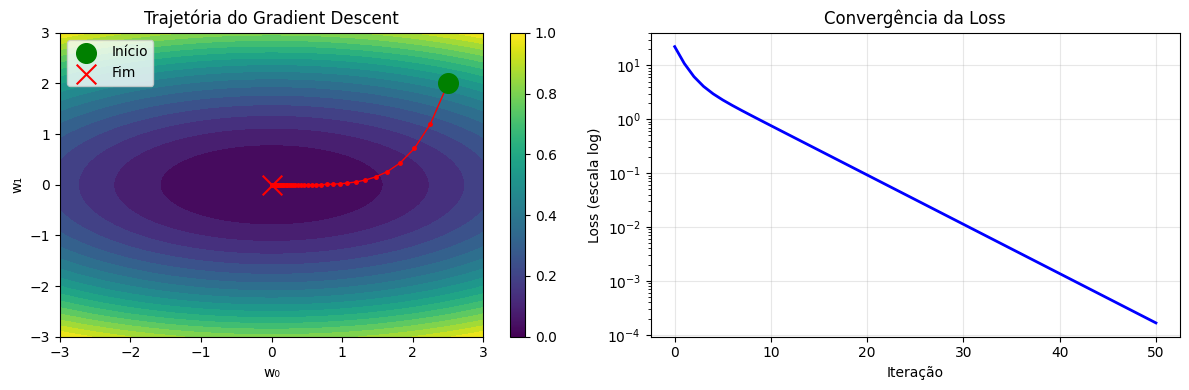

In [12]:
def loss_quadratic(w):
    return w[0]**2 + 4*w[1]**2

def grad_quadratic(w):
    return np.array([2*w[0], 8*w[1]])

# Gradient Descent
w = np.array([2.5, 2.0])  # inicialização
eta = 0.05  # learning rate
history = [w.copy()]

for t in range(50):
    grad = grad_quadratic(w)
    w = w - eta * grad
    history.append(w.copy())
    if (t+1) % 10 == 0:
        print(f'Iter {t+1}: w={w}, loss={loss_quadratic(w):.4f}')

history = np.array(history)

# Visualizar convergência
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Trajetória em contorno
w1 = np.linspace(-3, 3, 100)
w2 = np.linspace(-3, 3, 100)
W1, W2 = np.meshgrid(w1, w2)
Z = loss_quadratic(np.array([W1, W2]))

ax1.contourf(W1, W2, Z, levels=20, cmap='viridis')
ax1.plot(history[:, 0], history[:, 1], 'r.-', linewidth=1, markersize=5)
ax1.scatter(history[0, 0], history[0, 1], s=200, c='green', marker='o', label='Início', zorder=5)
ax1.scatter(history[-1, 0], history[-1, 1], s=200, c='red', marker='x', label='Fim', zorder=5)
ax1.set_xlabel('w₀')
ax1.set_ylabel('w₁')
ax1.set_title('Trajetória do Gradient Descent')
ax1.legend()
plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=ax1)

# Loss convergência
losses = [loss_quadratic(h) for h in history]
ax2.semilogy(range(len(losses)), losses, 'b-', linewidth=2)
ax2.set_xlabel('Iteração')
ax2.set_ylabel('Loss (escala log)')
ax2.set_title('Convergência da Loss')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**O que observar:**

- **Esquerda:** contorno com **ponto verde (inicio)** e **ponto vermelho X (fim)**. A linha vermelha com pontos mostra a trajetoria: como os parametros "andaram" pela paisagem de perda
- Note: trajetoria inicialmente "agressiva" (passos grandes longe do minimo), depois mais suave perto dele
- **Direita:** loss diminui exponencialmente (escala log!) a cada iteracao

**O que concluir:**

- **Convergencia funciona:** loss vai a zero seguindo o gradiente
- **Trajetoria em contorno:** desce sempre na direcao oposta ao gradiente local
- **Passos menores perto do minimo:** porque o gradiente fica pequeno ali (desaceleramento natural)
- **Convergencia exponencial** (reta em escala log): tipico de funcoes quadraticas convexas
- **Isso generaliza:** qualquer rede neural usa esse mesmo principio, so com mais dimensoes

**Conexao:** Falta uma peca: como calcular o gradiente eficientemente em redes com muitas camadas? A resposta eh Backpropagation (secao 14), mas antes precisamos das ferramentas matematicas: Jacobiano e Hessiano.

## 13. Jacobiano e Hessiano

### Generalizando Derivadas para Vetores e Matrizes

Ate aqui: derivada de funcao escalar. Mas em redes neurais, temos funcoes que recebem vetores e retornam vetores.

**Jacobiano:** Matriz de todas as derivadas parciais de primeira ordem de uma funcao vetorial.
- Para f: R^n -> R^m, o Jacobiano eh uma matriz m x n
- Cada linha i contem o gradiente da i-esima saida
- **Em ML:** O Jacobiano conecta como mudancas nos pesos afetam cada saida

**Hessiano:** Matriz de todas as derivadas parciais de segunda ordem de uma funcao escalar.
- Para f: R^n -> R, o Hessiano eh uma matriz n x n simetrica
- Captura a **curvatura** da funcao em todas as direcoes
- **Autovalores do Hessiano:** indicam se o ponto critico eh minimo (todos > 0), maximo (todos < 0) ou sela (misturados)

**Por que em ML:**
- **Jacobiano:** Essencial em backpropagation (propaga gradientes entre camadas)
- **Hessiano:** Usado em otimizadores de segunda ordem (Newton, L-BFGS). Muito custoso para redes grandes (matriz n^2 para n parametros), entao eh aproximado ou ignorado na pratica

In [13]:
# === GRADIENTE E JACOBIANO (Numeric) ===
# For multivariable functions

def jacobiano_numeric(f, x0, y0, h=1e-5):
    '''
    Compute Jacobian numerically for f: R² -> R
    Returns [df/dx, df/dy]
    '''
    df_dx = (f(x0 + h, y0) - f(x0 - h, y0)) / (2*h)
    df_dy = (f(x0, y0 + h) - f(x0, y0 - h)) / (2*h)
    return np.array([df_dx, df_dy])

# Função: f(x,y) = x² + 3xy + 2y²
def f_2d(x, y):
    return x**2 + 3*x*y + 2*y**2

# Gradiente esperado: [2x + 3y, 3x + 4y]
x0, y0 = 1.0, 2.0
grad = jacobiano_numeric(f_2d, x0, y0)
grad_expected = np.array([2*x0 + 3*y0, 3*x0 + 4*y0])

print('=== JACOBIANO (Funcao 2D) ===')
print(f'f(x,y) = x² + 3xy + 2y²')
print(f'Ponto: ({x0}, {y0})')
print(f'Gradiente numerico: {grad}')
print(f'Gradiente esperado: {grad_expected}')
print(f'Diferenca: {np.abs(grad - grad_expected).max():.2e}')

# Hessiana (segunda derivada)
def hessiana_numeric(f, x0, y0, h=1e-4):
    '''Compute Hessian (2x2 matrix of second partials)'''
    # f_xx
    f_xx = (f(x0+h, y0) - 2*f(x0, y0) + f(x0-h, y0)) / (h**2)
    # f_yy
    f_yy = (f(x0, y0+h) - 2*f(x0, y0) + f(x0, y0-h)) / (h**2)
    # f_xy (mixed partial)
    f_xy = (f(x0+h, y0+h) - f(x0+h, y0-h) - f(x0-h, y0+h) + f(x0-h, y0-h)) / (4*h**2)

    return np.array([[f_xx, f_xy], [f_xy, f_yy]])

hess = hessiana_numeric(f_2d, x0, y0)
hess_expected = np.array([[2, 3], [3, 4]])

print('\n=== HESSIANA ===')
print(f'Hessiana numerica:\n{hess}')
print(f'Hessiana esperada:\n{hess_expected}')
print(f'Diferenca maxima: {np.abs(hess - hess_expected).max():.2e}')

=== JACOBIANO (Funcao 2D) ===
f(x,y) = x² + 3xy + 2y²
Ponto: (1.0, 2.0)
Gradiente numerico: [ 8. 11.]
Gradiente esperado: [ 8. 11.]
Diferenca: 1.16e-10

=== HESSIANA ===
Hessiana numerica:
[[1.99999999 2.99999994]
 [2.99999994 4.00000033]]
Hessiana esperada:
[[2 3]
 [3 4]]
Diferenca maxima: 3.31e-07


**O que observar:**

- O **gradiente** (Jacobiano para funcao escalar) tem duas componentes: dF/dx = 2x + 3y e dF/dy = 3x + 4y
- O **Hessiano** eh uma matriz 2x2 constante (porque f eh quadratica)
- **Determinante > 0** e **traco > 0** confirmam que a funcao eh convexa
- **Autovalores positivos** significam: qualquer direcao que voce olhe, a funcao curva para cima

**O que concluir:**

- **Jacobiano/gradiente = direcao de movimento** (informacao de 1a ordem)
- **Hessiano = curvatura** (informacao de 2a ordem)
- **Hessiano definido positivo** (autovalores > 0) = funcao convexa localmente = minimo garantido
- **Em deep learning:** Hessiano eh proibitivamente caro para milhoes de parametros, entao otimizadores como Adam **aproximam** a informacao de curvatura indiretamente

**Conexao:** Agora temos todas as ferramentas. Vamos junta-las na implementacao completa de Backpropagation.

## 14. Backpropagation: Regra da Cadeia em Redes Neurais

### O Algoritmo que Permite Redes Profundas Aprenderem

Backpropagation nao eh nada mais que a **regra da cadeia aplicada sistematicamente** a cada camada da rede.

**Forward Pass** (calcular predicao):
```
z1 = X @ W1 + b1       # pre-ativacao camada 1
h1 = ativacao(z1)       # saida camada 1
z2 = h1 @ W2 + b2      # pre-ativacao camada 2
y_hat = ativacao(z2)    # predicao final
```

**Backward Pass** (calcular gradientes, da saida para a entrada):
```
dL/dy_hat = ...                       # gradiente da loss
dL/dz2 = dL/dy_hat * ativacao'(z2)   # regra da cadeia!
dL/dW2 = h1.T @ dL/dz2              # gradiente dos pesos
dL/dh1 = dL/dz2 @ W2.T              # propaga para camada anterior
dL/dz1 = dL/dh1 * ativacao'(z1)     # regra da cadeia de novo!
dL/dW1 = X.T @ dL/dz1               # gradiente dos pesos da camada 1
```

**Observe o padrao:** Em cada camada, o gradiente eh multiplicado pela derivada da ativacao. Isso explica:
- **Vanishing gradients com sigmoid:** derivada max = 0.25, entao gradiente encolhe exponencialmente
- **Estabilidade com ReLU:** derivada = 1 para x > 0, gradiente passa sem encolher

In [14]:
# Rede neural simples: X → W1 → ReLU → W2 → Sigmoid → ŷ
def relu(x):
    return np.maximum(0, x)

def relu_prime(x):
    return (x > 0).astype(float)

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def sigmoid_prime(x):
    s = sigmoid(x)
    return s * (1 - s)

# Dados simulados
X = np.array([[1.0, 0.5], [2.0, 1.5]])
W1 = np.array([[0.5, 0.3], [0.2, 0.4]])
b1 = np.array([0.1, -0.1])
W2 = np.array([[0.6], [0.4]])
b2 = np.array([0.2])
y_true = np.array([[1.0], [0.0]])

print('=== FORWARD PASS ===')
z1 = X @ W1 + b1
h1 = relu(z1)
z2 = h1 @ W2 + b2
hat_y = sigmoid(z2)

print(f'X shape: {X.shape}')
print(f'z1: {z1.shape}, h1: {h1.shape}')
print(f'z2: {z2.shape}, ŷ: {hat_y.shape}')
print(f'ŷ = {hat_y.ravel()}')

print('\n=== BACKWARD PASS (Simplificado) ===')
print('Loss = MSE = 0.5 * (ŷ - y)²')
print('dL/dŷ = ŷ - y')
print('dL/dz2 = dL/dŷ * dŷ/dz2 = (ŷ - y) * sigmoid\'(z2)')
print('dL/dW2 = h1^T @ dL/dz2')
print('dL/dh1 = dL/dz2 @ W2^T * relu\'(z1)')
print('dL/dW1 = X^T @ dL/dh1')

=== FORWARD PASS ===
X shape: (2, 2)
z1: (2, 2), h1: (2, 2)
z2: (2, 1), ŷ: (2, 1)
ŷ = [0.68568011 0.81457258]

=== BACKWARD PASS (Simplificado) ===
Loss = MSE = 0.5 * (ŷ - y)²
dL/dŷ = ŷ - y
dL/dz2 = dL/dŷ * dŷ/dz2 = (ŷ - y) * sigmoid'(z2)
dL/dW2 = h1^T @ dL/dz2
dL/dh1 = dL/dz2 @ W2^T * relu'(z1)
dL/dW1 = X^T @ dL/dh1


**O que observar:**

- **Forward pass** processa dados da entrada para a saida, camada por camada
- As dimensoes se transformam: (2,2) -> (2,2) -> (2,1) (compressao gradual)
- **Backward pass** mostra as formulas de gradiente para cada parametro

**O que concluir:**

- **Backprop = regra da cadeia sistematica** -- nada mais, nada menos
- **Custo computacional:** proporcional ao forward pass (eficiente!)
- **Cada camada precisa de:** (1) derivada da ativacao e (2) gradiente da camada seguinte
- **Frameworks modernos** (PyTorch, TensorFlow) fazem isso automaticamente com autograd
- **Na pratica:** voce raramente implementa backprop manualmente, mas entender o mecanismo eh essencial para debugar e projetar arquiteturas

**Padrao geral do backward pass:**
1. Comeca com dL/dy_hat (gradiente da funcao de perda)
2. Multiplica pela derivada da ativacao em cada camada
3. Propaga para tras usando as matrizes de peso transpostas
4. Acumula gradientes para atualizar os pesos

## 15. Exercicios Praticos

### Exercicio 1: Derivar MSE e Implementar Gradient Descent Linear

**Tarefa:**

A funcao de custo MSE (Mean Squared Error) eh: L = (1/n) * sum((y_pred - y_true)^2)

1. Calcule dL/dy_pred (derivada em relacao as predicoes)
2. Para y_pred = w*x + b, calcule dL/dw e dL/db usando a regra da cadeia
3. Implemente gradient descent manualmente para encontrar w e b otimos
4. Verifique que os parametros convergem

**Dica:** Comece com um dataset pequeno (5 pontos) para facilitar o debug.

In [15]:
# === EXERCICIO 1: Derivada de MSE + Gradient Descent Linear ===
# Dados simples
X_ex = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y_ex = np.array([2.1, 4.0, 5.8, 8.1, 9.9])  # aproximadamente y = 2x + 0

# TAREFA DO ALUNO: Inicialize w e b
w = None  # Substitua
b = None  # Substitua
eta = None  # Learning rate

# TAREFA DO ALUNO: Implemente gradient descent
# Para cada iteracao:
#   1. y_pred = w * X_ex + b
#   2. loss = mean((y_pred - y_ex)^2)
#   3. dL_dw = (2/n) * sum((y_pred - y_ex) * X_ex)
#   4. dL_db = (2/n) * sum(y_pred - y_ex)
#   5. w = w - eta * dL_dw
#   6. b = b - eta * dL_db

num_iters = 100
losses_ex1 = []

for t in range(num_iters):
    pass  # TAREFA DO ALUNO: implemente os 6 passos descritos acima

print("Implemente o gradient descent para regressao linear!")

Implemente o gradient descent para regressao linear!


=== Exercicio 1: Derivada de MSE + Gradient Descent Linear ===

Iter 50: w=1.8667, b=0.4429, loss=0.037289
Iter 100: w=1.8828, b=0.3849, loss=0.029967
Iter 150: w=1.8964, b=0.3358, loss=0.024748
Iter 200: w=1.9078, b=0.2944, loss=0.021028

Resultado final: y = 1.9078*x + 0.2944
Esperado: y ~ 2.0*x + 0.0


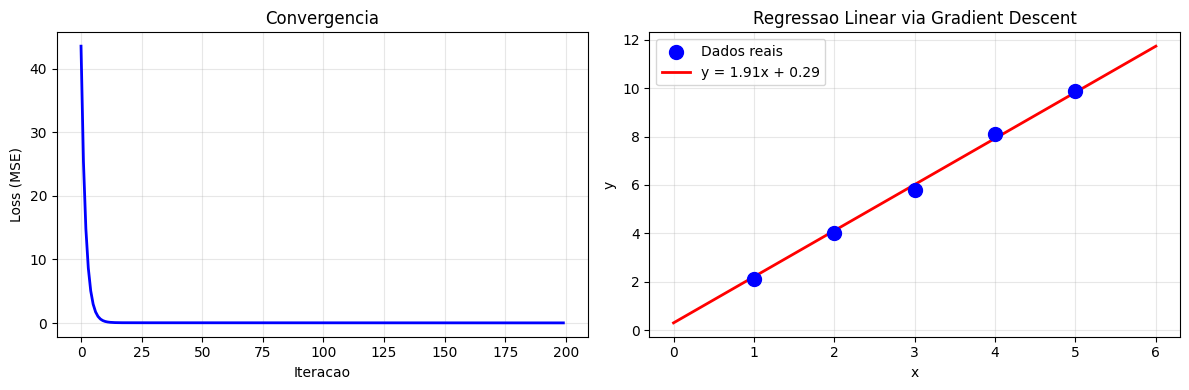

In [16]:
# === SOLUCAO EXERCICIO 1 ===
print('=== Exercicio 1: Derivada de MSE + Gradient Descent Linear ===\n')

X_ex = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y_ex = np.array([2.1, 4.0, 5.8, 8.1, 9.9])
n = len(X_ex)

# Derivacao:
# L = (1/n) * sum((w*x + b - y)^2)
# dL/dw = (2/n) * sum((w*x + b - y) * x)
# dL/db = (2/n) * sum(w*x + b - y)

w, b = 0.0, 0.0
eta = 0.01
num_iters = 200
losses_ex1 = []

for t in range(num_iters):
    y_pred = w * X_ex + b
    loss = np.mean((y_pred - y_ex)**2)
    losses_ex1.append(loss)

    dL_dw = (2/n) * np.sum((y_pred - y_ex) * X_ex)
    dL_db = (2/n) * np.sum(y_pred - y_ex)

    w -= eta * dL_dw
    b -= eta * dL_db

    if (t+1) % 50 == 0:
        print(f'Iter {t+1}: w={w:.4f}, b={b:.4f}, loss={loss:.6f}')

print(f'\nResultado final: y = {w:.4f}*x + {b:.4f}')
print(f'Esperado: y ~ 2.0*x + 0.0')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(losses_ex1, 'b-', linewidth=2)
ax1.set_xlabel('Iteracao'); ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Convergencia'); ax1.grid(True, alpha=0.3)

ax2.scatter(X_ex, y_ex, s=100, c='blue', label='Dados reais', zorder=5)
x_line = np.linspace(0, 6, 100)
ax2.plot(x_line, w*x_line + b, 'r-', linewidth=2, label=f'y = {w:.2f}x + {b:.2f}')
ax2.set_xlabel('x'); ax2.set_ylabel('y')
ax2.set_title('Regressao Linear via Gradient Descent'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Exercicio 2: Derivar Cross-Entropy e Verificar a "Magica" da Sigmoid

**Tarefa:**

A funcao de custo Cross-Entropy binaria eh: L = -(1/n) * sum[y*log(y_hat) + (1-y)*log(1-y_hat)]

1. Calcule dL/dy_hat algebricamente
2. Para y_hat = sigmoid(z) onde z = X @ w + b, aplique a regra da cadeia
3. Mostre que dL/dz = y_hat - y (simplificacao notavel!)
4. Implemente gradient descent para regressao logistica simples (dados com 4 pontos)

**Dica:** A derivada de sigmoid eh sigmoid(z) * (1 - sigmoid(z)). Quando combinada com cross-entropy, tudo simplifica.

In [17]:
# === EXERCICIO 2: Cross-Entropy + Sigmoid ===
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

# Dados simples (porta OR)
X_ex2 = np.array([[0.0, 0.0], [1.0, 0.0], [0.0, 1.0], [1.0, 1.0]])
y_ex2 = np.array([[0.0], [1.0], [1.0], [1.0]])

# TAREFA DO ALUNO: Inicialize w (2x1) e b (1x1) aleatorios
w = None  # Substitua
b = None  # Substitua
eta = 0.5
num_iters = 200

# TAREFA DO ALUNO: Loop de gradient descent
# Para cada iteracao:
#   1. z = X_ex2 @ w + b
#   2. y_hat = sigmoid(z)
#   3. loss = -mean(y*log(y_hat + eps) + (1-y)*log(1-y_hat + eps))
#   4. dL_dz = y_hat - y_ex2   <-- a "magica"!
#   5. dL_dw = X_ex2.T @ dL_dz / n
#   6. dL_db = mean(dL_dz)

print("Implemente regressao logistica com cross-entropy!")

Implemente regressao logistica com cross-entropy!


=== Exercicio 2: Cross-Entropy + Sigmoid ===

Derivacao:
dL/dy_hat = -y/y_hat + (1-y)/(1-y_hat)
dy_hat/dz = sigmoid(z) * (1 - sigmoid(z))
dL/dz = dL/dy_hat * dy_hat/dz = (y_hat - y)  <- MAGICA!

Predicoes finais:
  Input [0. 0.] -> P(y=1) = 0.1867 (real: 0)
  Input [1. 0.] -> P(y=1) = 0.9277 (real: 1)
  Input [0. 1.] -> P(y=1) = 0.9274 (real: 1)
  Input [1. 1.] -> P(y=1) = 0.9986 (real: 1)


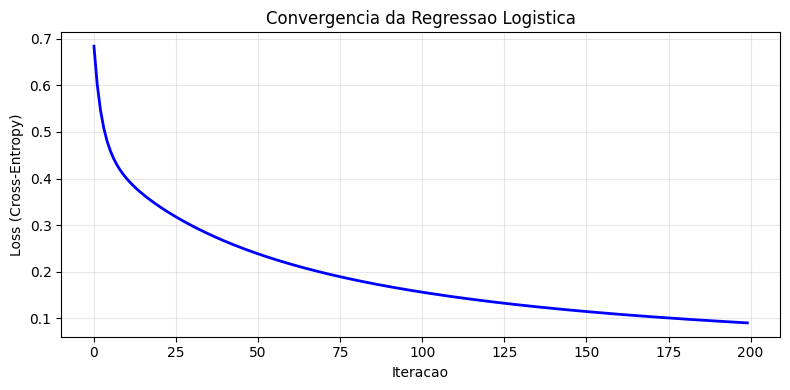

In [18]:
# === SOLUCAO EXERCICIO 2 ===
print('=== Exercicio 2: Cross-Entropy + Sigmoid ===\n')

# Derivacao algebrica:
# dL/dy_hat = -y/y_hat + (1-y)/(1-y_hat) = (y_hat - y) / (y_hat*(1-y_hat))
# dy_hat/dz = y_hat * (1 - y_hat)   [derivada da sigmoid]
# dL/dz = dL/dy_hat * dy_hat/dz = (y_hat - y)  <-- simplifica!

print('Derivacao:')
print('dL/dy_hat = -y/y_hat + (1-y)/(1-y_hat)')
print('dy_hat/dz = sigmoid(z) * (1 - sigmoid(z))')
print('dL/dz = dL/dy_hat * dy_hat/dz = (y_hat - y)  <- MAGICA!\n')

X_ex2 = np.array([[0.0, 0.0], [1.0, 0.0], [0.0, 1.0], [1.0, 1.0]])
y_ex2 = np.array([[0.0], [1.0], [1.0], [1.0]])
n = len(X_ex2)

w = np.random.randn(2, 1) * 0.1
b = np.zeros((1, 1))
eta = 0.5
num_iters = 200
losses_ex2 = []

for t in range(num_iters):
    z = X_ex2 @ w + b
    y_hat = sigmoid(z)
    eps = 1e-10
    loss = -np.mean(y_ex2 * np.log(y_hat + eps) + (1 - y_ex2) * np.log(1 - y_hat + eps))
    losses_ex2.append(loss)

    dz = y_hat - y_ex2  # A simplificacao notavel!
    dw = X_ex2.T @ dz / n
    db = np.mean(dz)

    w -= eta * dw
    b -= eta * db

y_final = sigmoid(X_ex2 @ w + b)
print('Predicoes finais:')
for i in range(n):
    print(f'  Input {X_ex2[i]} -> P(y=1) = {y_final[i,0]:.4f} (real: {y_ex2[i,0]:.0f})')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(losses_ex2, 'b-', linewidth=2)
ax.set_xlabel('Iteracao'); ax.set_ylabel('Loss (Cross-Entropy)')
ax.set_title('Convergencia da Regressao Logistica'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Exercicio 3: Gradient Descent em Regressao Logistica com Dataset Real

**Tarefa:**

Use sklearn.datasets.make_classification para gerar dados reais:

1. Gere 200 amostras com 5 features (3 informativas, 1 redundante)
2. Normalize com StandardScaler
3. Implemente regressao logistica com gradient descent do zero
4. Plote a curva de loss vs iteracoes
5. Calcule a acuracia nos dados de treino
6. Mostre a distribuicao de probabilidades preditas por classe

**Dica:** Use sigmoid segura (clip em [-500, 500]) para evitar overflow.

In [19]:
# === EXERCICIO 3: Gradient Descent com Regressao Logistica (Numpy) ===
# Using synthetic data and numpy instead of sklearn

# Gerar dados sinteticos
np.random.seed(42)
n_samples = 200
X = np.random.randn(n_samples, 2) * 2
y = (X[:, 0] + X[:, 1] > 0).astype(int)

# Normalizar features
X = (X - X.mean(axis=0)) / X.std(axis=0)

# Funcao logistica
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

# Funcao custo (binary cross-entropy)
def logistic_loss(w, b, X, y):
    z = X @ w + b
    p = sigmoid(z)
    eps = 1e-15
    p = np.clip(p, eps, 1-eps)
    return -np.mean(y * np.log(p) + (1-y) * np.log(1-p))

# Gradiente (numerical)
def gradient_numeric(w, b, X, y, h=1e-5):
    dw = np.zeros_like(w)
    for i in range(len(w)):
        w_plus = w.copy()
        w_plus[i] += h
        dw[i] = (logistic_loss(w_plus, b, X, y) - logistic_loss(w, b, X, y)) / h

    db = (logistic_loss(w, b+h, X, y) - logistic_loss(w, b-h, X, y)) / (2*h)
    return dw, db

# Gradient Descent
w = np.random.randn(2) * 0.01
b = 0.0
learning_rate = 0.1
n_iterations = 100

print('=== EXERCICIO 3: Gradient Descent em Regressao Logistica ===')
print(f'Initial loss: {logistic_loss(w, b, X, y):.4f}')

for iteration in range(n_iterations):
    dw, db = gradient_numeric(w, b, X, y, h=1e-5)

    w -= learning_rate * dw
    b -= learning_rate * db

    if (iteration + 1) % 20 == 0:
        loss = logistic_loss(w, b, X, y)
        print(f'Iteration {iteration+1}: loss = {loss:.4f}')

print(f'Final loss: {logistic_loss(w, b, X, y):.4f}')
print(f'Learned weights: w = {w}')
print(f'Learned bias: b = {b:.4f}')

# Verificar predicoes
z = X @ w + b
y_pred = (sigmoid(z) > 0.5).astype(int)
accuracy = np.mean(y_pred == y)
print(f'Accuracy: {accuracy:.2%}')

=== EXERCICIO 3: Gradient Descent em Regressao Logistica ===
Initial loss: 0.6995
Iteration 20: loss = 0.4892
Iteration 40: loss = 0.3935


Iteration 60: loss = 0.3389
Iteration 80: loss = 0.3030
Iteration 100: loss = 0.2771
Final loss: 0.2771
Learned weights: w = [1.43284257 1.23938175]
Learned bias: b = 0.0061
Accuracy: 99.50%


In [20]:
# === EXERCICIO 3: Gradient Descent em Regressao Logistica ===
# TAREFA DO ALUNO: Implementar gradient descent para regressao logistica
# Use sigmoid e cross-entropy loss

np.random.seed(42)
X_ex3 = np.random.randn(50, 2)
y_ex3 = (X_ex3[:, 0] + X_ex3[:, 1] > 0).astype(float)

w_ex3 = None  # TAREFA DO ALUNO: inicializar pesos
lr_ex3 = None  # TAREFA DO ALUNO: definir learning rate
losses_ex3 = None  # TAREFA DO ALUNO: lista para guardar losses

In [21]:
# SOLUCAO EXERCICIO 3
print('\n=== EXERCICIO 3: Gradient Descent em Regressao Logistica ===')

# Reproducao completa
np.random.seed(42)
n_samples = 200
X = np.random.randn(n_samples, 2) * 2
y = (X[:, 0] + X[:, 1] > 0).astype(int)
X = (X - X.mean(axis=0)) / X.std(axis=0)

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def logistic_loss(w, b, X, y):
    z = X @ w + b
    p = sigmoid(z)
    eps = 1e-15
    p = np.clip(p, eps, 1-eps)
    return -np.mean(y * np.log(p) + (1-y) * np.log(1-p))

# Gradient Descent with analytical gradient (better for solution)
def logistic_gradient(w, b, X, y):
    z = X @ w + b
    p = sigmoid(z)
    dw = X.T @ (p - y) / len(y)
    db = np.mean(p - y)
    return dw, db

w = np.zeros(2)
b = 0.0
learning_rate = 0.5
n_iterations = 100
losses = []

for iteration in range(n_iterations):
    dw, db = logistic_gradient(w, b, X, y)
    w -= learning_rate * dw
    b -= learning_rate * db
    loss = logistic_loss(w, b, X, y)
    losses.append(loss)

# Resultado
z = X @ w + b
y_pred = (sigmoid(z) > 0.5).astype(int)
accuracy = np.mean(y_pred == y)

print(f'Loss final: {losses[-1]:.4f}')
print(f'Accuracy: {accuracy:.2%}')
print(f'Weights: {w}')
print(f'Bias: {b:.4f}')


=== EXERCICIO 3: Gradient Descent em Regressao Logistica ===
Loss final: 0.1423
Accuracy: 99.50%
Weights: [3.06591748 2.74466029]
Bias: 0.0675


## 16. Erros Comuns

### 1. Confundir derivada parcial com derivada total

**Errado:** "dL/dw1 considera como w2 muda junto"

**Certo:** Derivada parcial dL/dw1 fixa todos os outros parametros. Cada parametro tem seu proprio gradiente independente.

### 2. Esquecer o fator 1/n no gradiente da loss

**Errado:** dL/dw = sum((y_hat - y) * x)

**Certo:** dL/dw = (1/n) * sum((y_hat - y) * x) -- sem o 1/n, o gradiente escala com o tamanho do batch, e o learning rate efetivo muda com o batch size.

### 3. Derivada numerica unilateral em vez de centrada

**Errado:** (f(x+h) - f(x)) / h -- erro O(h)

**Certo:** (f(x+h) - f(x-h)) / (2h) -- erro O(h^2). Para h = 1e-5, a centrada eh 10000x mais precisa!

### 4. Assumir que sigmoid'(x) = sigmoid(x)

**Errado:** sigma'(x) = sigma(x)

**Certo:** sigma'(x) = sigma(x) * (1 - sigma(x)). Isso faz a derivada maxima ser apenas 0.25 (em x=0), causando vanishing gradients.

### 5. Learning rate inadequado

**Sintoma:** Loss oscila ou diverge (eta muito grande) OU loss diminui muito lentamente (eta muito pequeno).

**Diagnostico rapido:**
- Se loss AUMENTA: reduza eta por 10x
- Se loss diminui mas muito lento: aumente eta por 2-3x
- Se loss oscila sem convergir: reduza eta por 3-5x

### 6. Overflow numerico na sigmoid/softmax

**Errado:** sigmoid(z) = 1/(1 + exp(-z)) -- exp(1000) = infinito!

**Certo:** Clipar z antes: sigmoid(clip(z, -500, 500)). Ou usar a versao estavel: para z >= 0 use 1/(1+exp(-z)), para z < 0 use exp(z)/(1+exp(z)).

### 7. Nao normalizar os dados antes de gradient descent

**Sintoma:** Convergencia muito lenta ou instavel.

**Por que:** Se features tem escalas muito diferentes (ex: idade 0-100 vs salario 0-100000), o gradiente em relacao a cada feature tem magnitudes muito diferentes. Isso cria uma "paisagem" alongada onde gradient descent "zigzagueia".

**Solucao:** Sempre use StandardScaler ou similar antes de treinar.

## 17. Resumo: De Limites a Deep Learning

### Hierarquia de Conceitos

```
Limites (Sec 2)
  |
  v
Derivadas (Sec 3-6)          "Qual a taxa de mudanca?"
  |
  +-- Basicas (Sec 4)         Tabela de formulas
  +-- Regras (Sec 5)          Soma, produto, quociente
  +-- Cadeia (Sec 6)          FUNDAMENTO de backprop
  |
  v
Derivadas Parciais (Sec 10)   "Como varia em cada direcao?"
  |
  v
Gradiente (Sec 11)            "Vetor de todas as parciais"
  |
  v
Gradient Descent (Sec 12)     "Descer na direcao oposta ao gradiente"
  |
  v
Backpropagation (Sec 14)      "Regra da cadeia em redes neurais"
```

### Conexoes-Chave

| Conceito | Conecta com | Como |
|----------|-------------|------|
| Regra da Cadeia | Backpropagation | Cada camada multiplica derivada local |
| ReLU vs Sigmoid | Vanishing gradients | Derivada 1 vs max 0.25 |
| Segunda derivada | Otimizadores avancados | Curvatura guia tamanho do passo |
| Gradient Descent | Todo treinamento em ML | w <- w - eta * grad |
| Gradient Checking | Debug de backprop | Compara numerico vs analitico |

### Checklist de Aprendizado

- [ ] Sei explicar o que eh uma derivada sem usar formulas
- [ ] Consigo derivar funcoes basicas (polinomios, exp, log, trig)
- [ ] Entendo a regra da cadeia e por que eh fundamental para ML
- [ ] Sei a diferenca entre sigmoid, tanh e ReLU e quando usar cada uma
- [ ] Consigo implementar gradient descent do zero
- [ ] Entendo por que ReLU evita vanishing gradients
- [ ] Sei o que eh gradient checking e quando usar
- [ ] Consigo explicar backpropagation como "regra da cadeia sistematica"
- [ ] Entendo o papel do learning rate e como diagnosticar problemas
- [ ] Sei o que Jacobiano e Hessiano representam geometricamente

### Proximo Notebook

**0.5 - Calculo II: Integrais e Series**

Integrais sao o "inverso" de derivadas. Em ML, aparecem em:
- Calculo de probabilidades (area sob a curva)
- Valor esperado de distribuicoes
- Funcoes de perda baseadas em divergencia (KL divergence)
- Series de Taylor para aproximar funcoes (base de muitas otimizacoes)

Tambem usaremos derivadas deste notebook extensivamente em:
- **Notebook 4.1:** Redes neurais -- backpropagation completo
- **Notebook 0.8:** Otimizacao -- SGD, Adam, e variantes

## Conexao com Algebra Linear (0.2, 0.3)

A derivada de uma **funcao linear** é exatamente a **matriz que multiplica o vetor**.
Se f(x) = Ax (transformacao linear), entao df/dx = A.

Isto é porque:
- Gradiente = Jacobiano para funcoes escalar -> vetorial
- Hessiana = matriz simetrica (2ª derivada)
- Multiplicacao matricial é diferenciavel!

Por isso em ML, a maioria das operacoes (camadas neurais) precisa ser diferenciavel em relacao aos parametros.

### Conexao com Calculo Vetorial

Quando temos f: R^n -> R (n variaveis), o **gradiente** é o vetor de derivadas parciais.

Propriedade: ∇f aponta na direcao de **maior crescimento**!

Em ML: Gradient Descent segue -∇f porque quer DESCER a funcao de custo.

### Conexao com Series de Taylor

Toda funcao diferenciavel pode ser aproximada por um polinomio (sua serie de Taylor):

f(x) ≈ f(a) + f'(a)(x-a) + f''(a)(x-a)²/2 + ...

A **primeira derivada** já da uma boa aproximacao linear (1ª ordem).
Isto é exatamente o que Newton's Method e Taylor expansion fazem em otimizacao!

### Conexao com Dinamica de Sistemas

Se y(t) é uma posicao no tempo, entao:
- dy/dt = velocidade
- d²y/dt² = aceleracao

Em **redes neurais recorrentes (RNNs)**, os estados evoluem conforme uma regra:
h_{t+1} = f(h_t, x_t)

A derivada dh/dt governa como o estado muda -- exatamente como em EDOs (Equacoes Diferenciais Ordinarias).

### Por que em ML: Otimizacao com Gradiente

**Gradient Descent** é o algoritmo fundamental de ML. Ele funciona:

1. Calcula-se ∇Loss em relacao aos parametros
2. Atualiza-se: parametro -= learning_rate * gradiente
3. Repete-se ate convergencia

Sem derivadas, nao temos direcao para ajustar pesos. Derivadas sao o mapa de calor para encontrar o minimo!

### Por que em ML: Backpropagation

Toda rede neural usa a **regra da cadeia** para calcular gradientes:

d(Loss)/d(w_layer1) = d(Loss)/d(output) * d(output)/d(hidden) * d(hidden)/d(w_layer1)

Isto é computado de tras para frente (back) na rede. Sem a regra da cadeia, backprop nao existe!

### Por que em ML: Verificacao Numerica

Na pratica, implementamos gradientes e testamos com **gradient checking**:
- Calcula-se derivada numerica (h -> 0): (f(x+h) - f(x-h)) / 2h
- Compara-se com derivada analitica
- Se diferenca > 1e-4, ha bug no codigo!

Isto é absolutamente critico em producao.

### Erro 1: Confundir "derivada" com "taxa media"

**Errado**: "A derivada de f(x)=x² é o valor f(3)-f(0) = 9"

**Certo**: A **taxa media** é (f(3)-f(0))/3 = 3. A **derivada em x=1.5** é f'(1.5)=3.

A derivada é no **ponto exato**, nao a mudanca total!

### Erro 2: Esquecer da regra da cadeia

**Errado**: d/dx[sin(x²)] = cos(x)

**Certo**: d/dx[sin(x²)] = cos(x²) * 2x

Sempre: d/dx[g(f(x))] = g'(f(x)) * f'(x)

### Erro 3: Ordem das operacoes na regra do produto

**Errado**: d/dx[u*v] = u'*v'

**Certo**: d/dx[u*v] = u'*v + u*v'

Sempre somar (nao multiplicar) os termos!

### Erro 4: Numericamente, usar h muito pequeno ou muito grande

**h=1e-15**: Erro de arredondamento (subtracao de numeros proximos)
**h=0.1**: Nao eh pequeno o bastante, derivada imprecisa

**Ideal**: h ≈ 1e-5 a 1e-7 (depende da escala da funcao)

### Erro 5: Esquecer que derivada parcial NAO eh gradiente

**Derivada parcial ∂f/∂x**: taxa de mudanca em relacao a UMA variavel (outras fixas)

**Gradiente ∇f**: vetor com TODAS as derivadas parciais

Em ML, a direcao de descida é sempre o gradiente completo, nao uma derivada parcial!

## Proximos Passos

Voce agora entende o **coração de ML**: como calcular e otimizar com gradientes.

### Caminho 1: Ir Mais Fundo em Otimizacao
- Proximas aulas: Integrais (inverso da derivada), Series de Taylor (aproximacoes polinomiais)
- Depois: Metodos avancados de otimizacao (Momentum, Adam, RMSprop)

### Caminho 2: Aplicar em Redes Neurais
- Implementar backprop com varias camadas
- Entender como cada derivada parcial flui de tras para frente
- Debugar com gradient checking

### Caminho 3: Geometria das Derivadas
- Quando o gradiente é zero? (pontos criticos)
- Como saber se é minimo ou maximo? (Teste da segunda derivada)
- Quando a Hessiana é importante? (curvatura)

### Desafio Final
Implementar do zero um otimizador tipo **Stochastic Gradient Descent (SGD)** e treinar em dataset real.
